# Crop Recommendation - Exploratory Data Analysis (EDA)

## Objective

In this notebook, we will:

- Load the crop recommendation dataset
- Explore the data
- Identify missing values
- Check duplicates
- Analyze feature distributions
- Detect outliers
- Study feature relationships
- Prepare the dataset for machine learning

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [3]:
crop_df = pd.read_csv("../data/raw/Crop_recommendation.csv")
crop_df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [4]:
crop_df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
crop_df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [7]:
crop_df.sample(5, random_state=42)

,N,P,K,temperature,humidity,ph,rainfall,label
1451,101,17,47,29.494014,94.729813,6.185053,26.308209,muskmelon
1334,98,8,51,26.179346,86.522581,6.259336,49.430510,watermelon
1761,59,62,49,43.360515,93.351916,6.941497,114.778071,papaya
1735,44,60,55,34.280461,90.555616,6.825371,98.540477,papaya
1576,30,137,200,22.914300,90.704756,5.603413,118.604465,apple


In [8]:
crop_df.shape

(2200, 8)

In [9]:
crop_df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [10]:
crop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [11]:
crop_df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


In [12]:
crop_df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [13]:
crop_df.duplicated().sum()

np.int64(0)

In [14]:
crop_df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

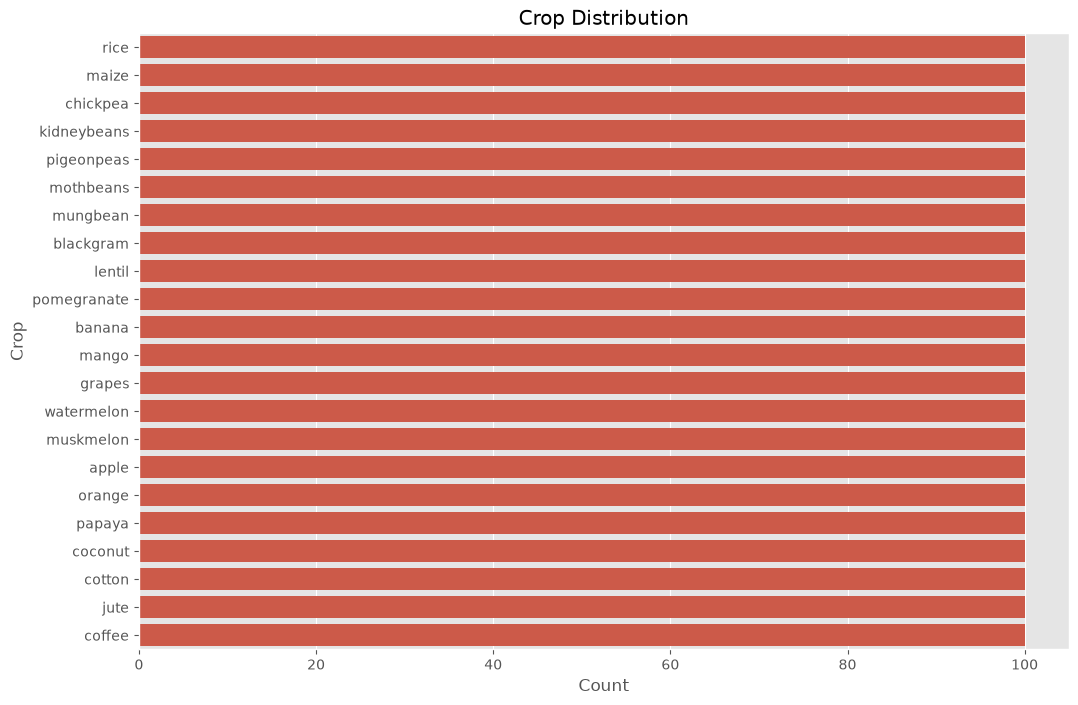

In [15]:
plt.figure(figsize=(12,8))

sns.countplot(
    y=crop_df["label"],
    order=crop_df["label"].value_counts().index
)

plt.title("Crop Distribution")
plt.xlabel("Count")
plt.ylabel("Crop")

plt.show()

In [16]:
num_cols = crop_df.select_dtypes(include=["int64", "float64"]).columns

num_cols

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='object')

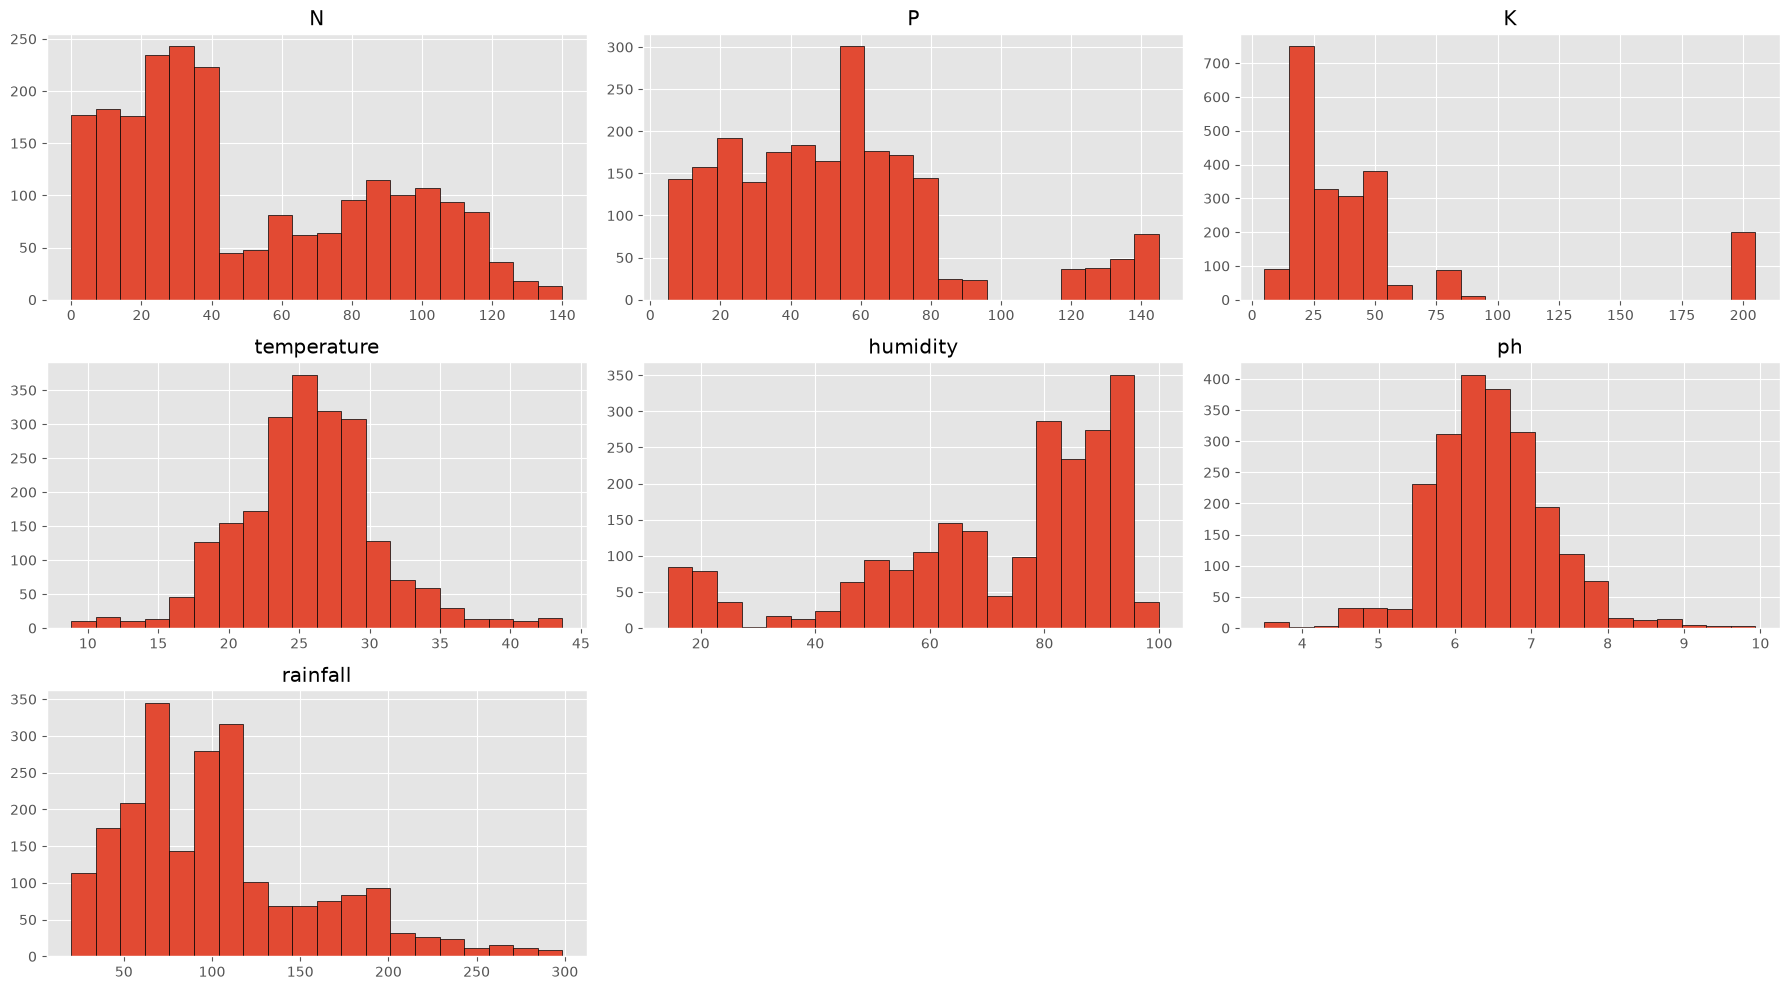

In [17]:
crop_df[num_cols].hist(
    figsize=(18,10),
    bins=20,
    edgecolor="black"
)

plt.tight_layout()

plt.show()

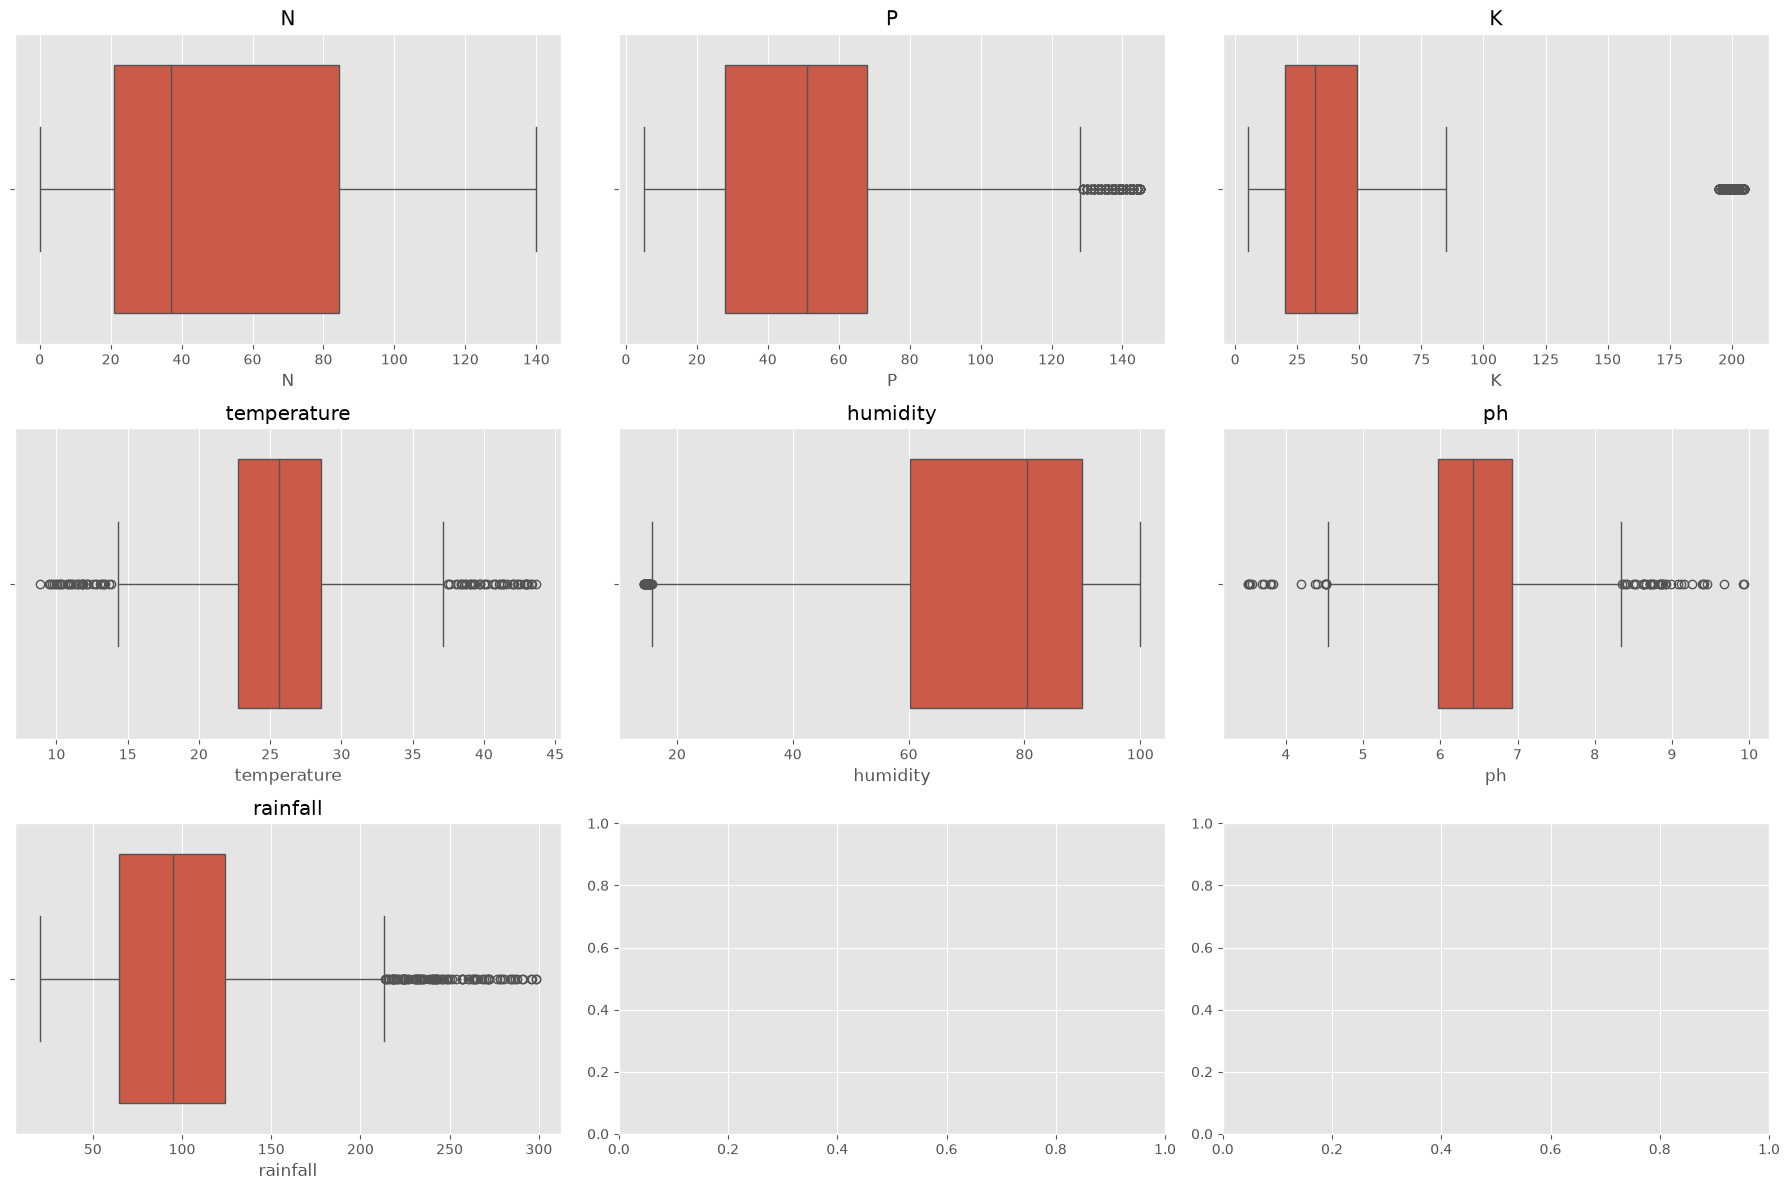

In [18]:
fig, axes = plt.subplots(3,3,figsize=(18,12))

axes = axes.flatten()

for i,col in enumerate(num_cols):

    sns.boxplot(x=crop_df[col], ax=axes[i])

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

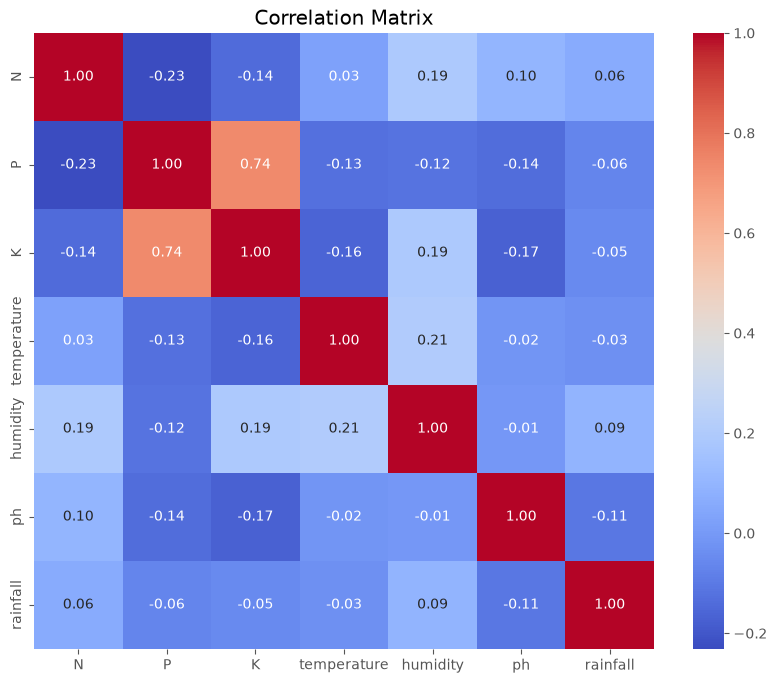

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(
    crop_df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Correlation Analysis

- Most features show weak correlations with each other.
- Phosphorus (P) and Potassium (K) have the highest positive correlation (0.74), but it is below the multicollinearity threshold.
- No feature needs to be removed based on correlation.
- All features will be retained for model training.

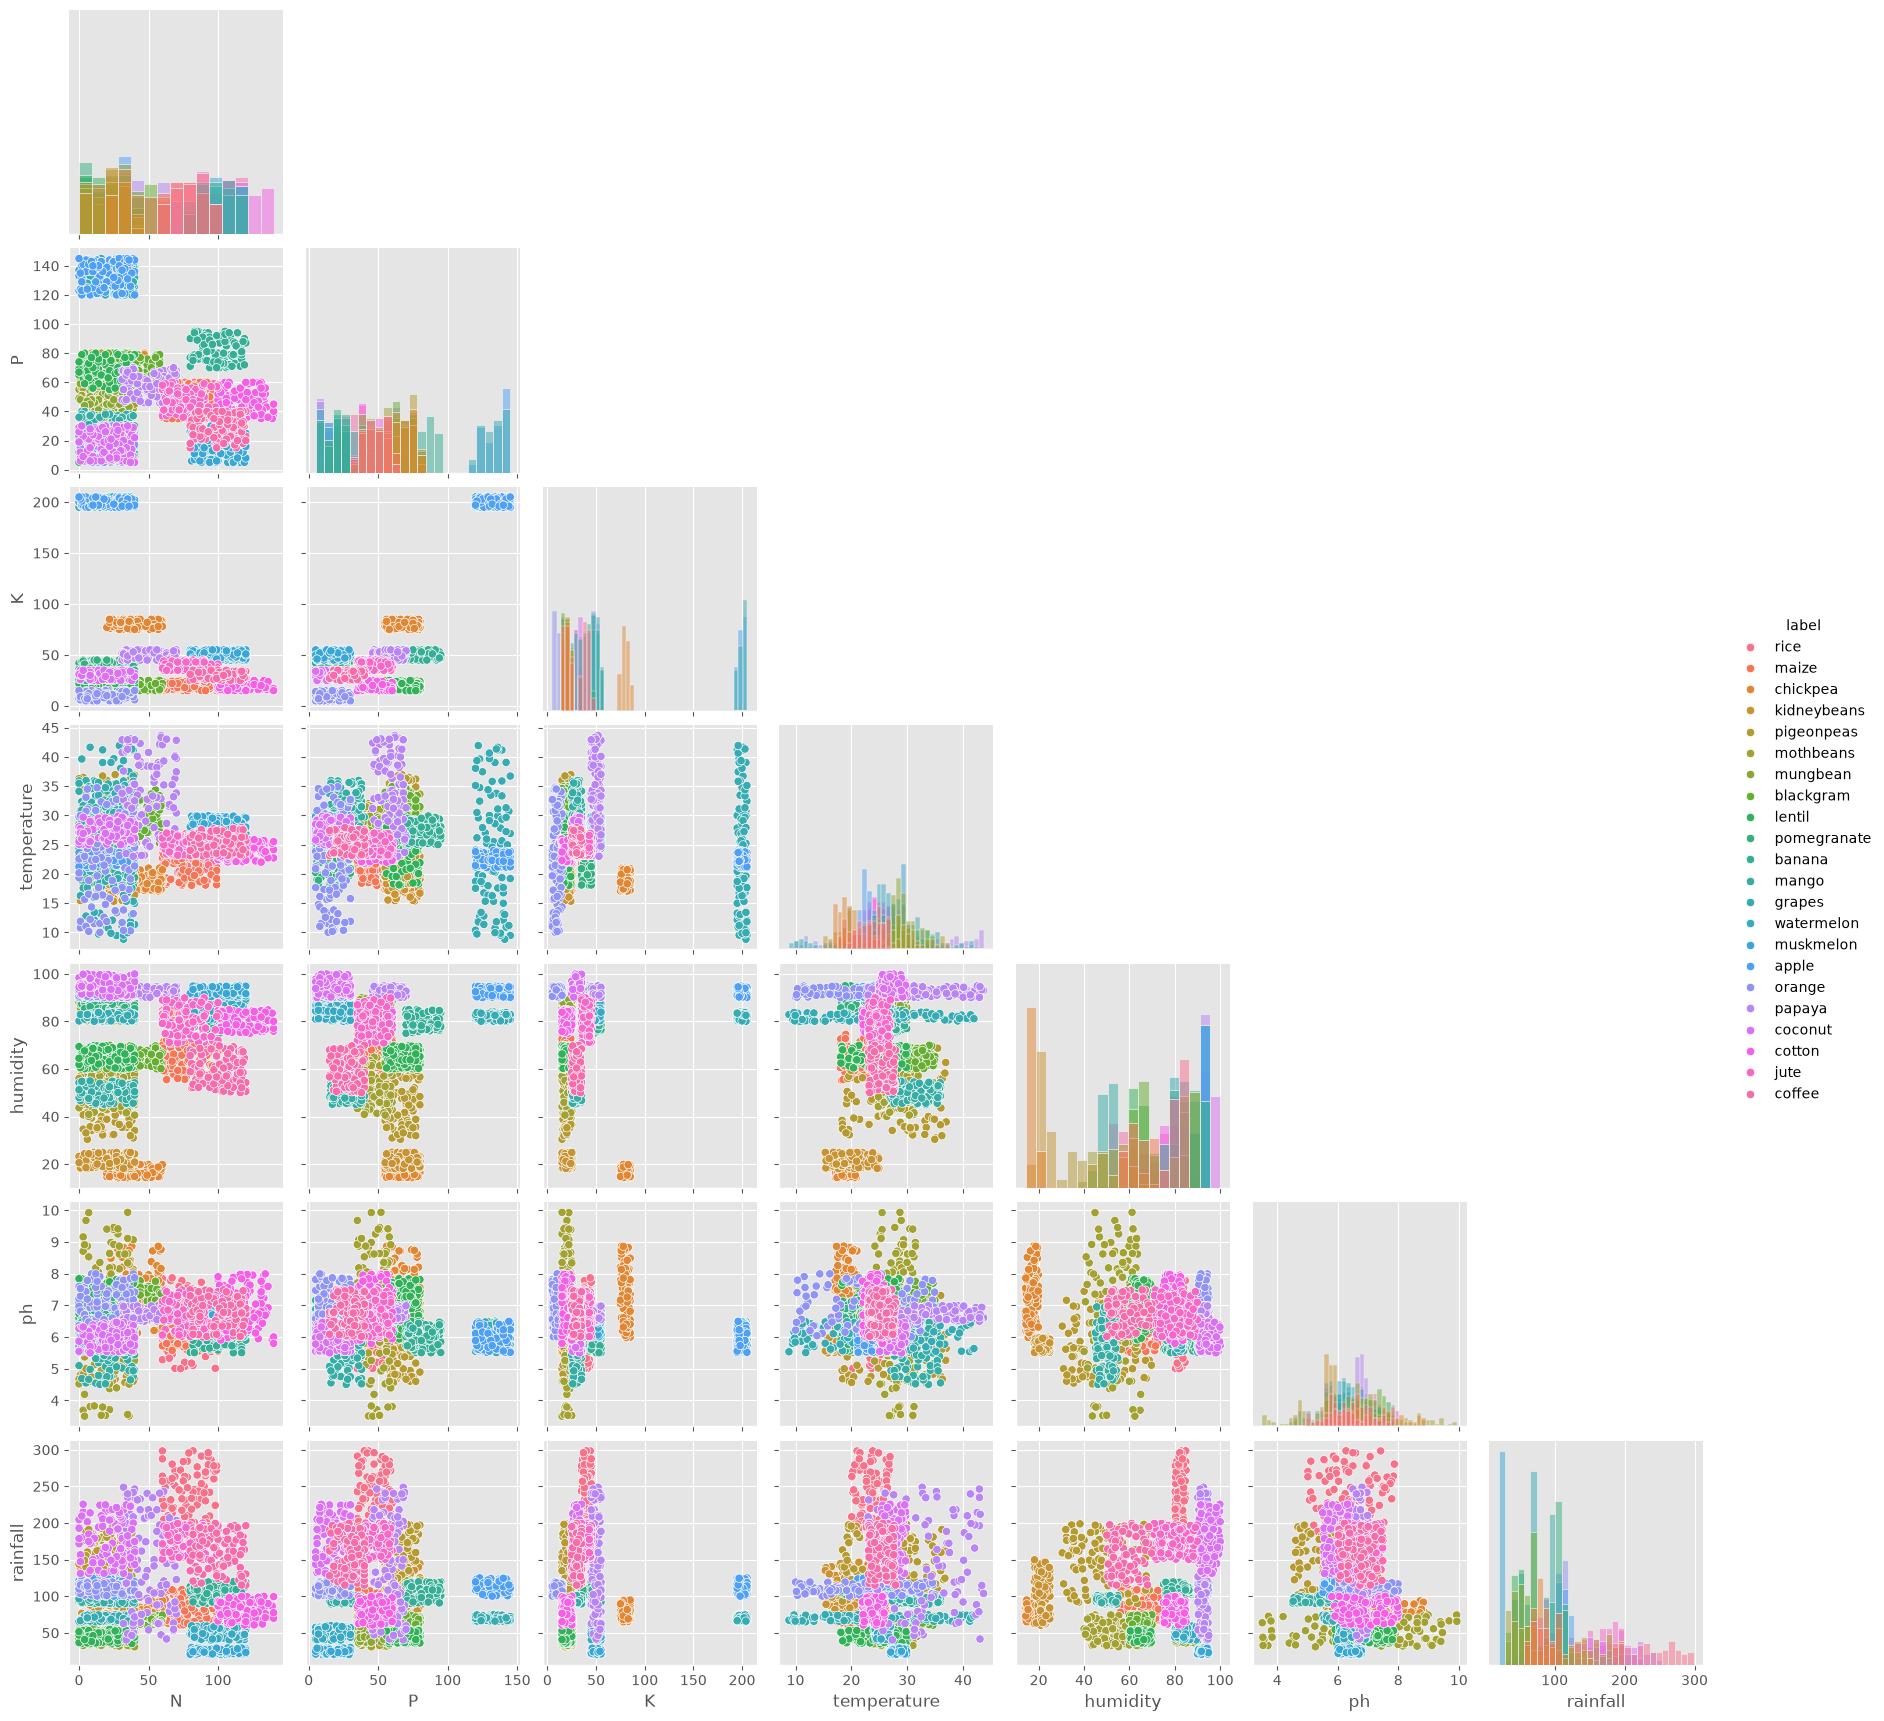

In [20]:
sns.pairplot(
    crop_df,
    hue="label",
    corner=True,
    diag_kind="hist"
)

plt.show()

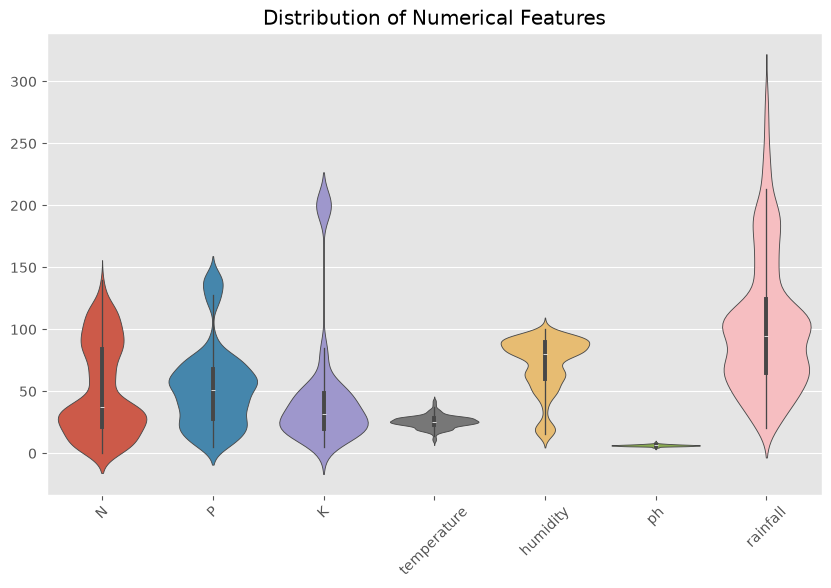

In [21]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=crop_df[num_cols]
)

plt.xticks(rotation=45)
plt.title("Distribution of Numerical Features")
plt.show()

In [22]:
for col in num_cols:
    Q1 = crop_df[col].quantile(0.25)
    Q3 = crop_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = crop_df[(crop_df[col] < lower) | (crop_df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

N: 0 outliers
P: 138 outliers
K: 200 outliers
temperature: 86 outliers
humidity: 30 outliers
ph: 57 outliers
rainfall: 100 outliers


# Final Exploratory Data Analysis (EDA) Summary

## Dataset Overview

- Total Records: **2200**
- Total Features: **8**
- Numerical Features: **7**
- Target Feature: **1 (Crop Label)**
- Total Crop Classes: **22**
- Dataset Status: **Balanced (100 samples per crop)**

---

## Data Quality Assessment

### Missing Values
- No missing values were found in the dataset.
- No imputation was required.

### Duplicate Records
- No duplicate records were detected.
- No duplicate removal was required.

### Class Distribution
- Each crop class contains 100 observations.
- The dataset is perfectly balanced, so no resampling techniques (SMOTE, undersampling, oversampling) are required.

---

## Feature Distribution

- Numerical features show different distributions across crops.
- Temperature and pH are approximately normally distributed.
- Rainfall, Nitrogen (N), Phosphorus (P), Potassium (K), and Humidity exhibit skewed or multimodal distributions due to varying crop requirements.

---

## Outlier Analysis

Outliers were detected using the IQR (Interquartile Range) method.

| Feature | Outliers |
|---------|----------:|
| Nitrogen (N) | 0 |
| Phosphorus (P) | 138 |
| Potassium (K) | 200 |
| Temperature | 86 |
| Humidity | 30 |
| pH | 57 |
| Rainfall | 100 |

Although statistical outliers exist, they were **not removed** because they represent valid agricultural conditions required by different crop species rather than erroneous observations. Removing these values could reduce the model's ability to learn crop-specific environmental requirements.

---

## Correlation Analysis

- Most numerical features exhibit weak correlations.
- The highest correlation was observed between **Phosphorus (P)** and **Potassium (K)** with a coefficient of **0.74**.
- No severe multicollinearity was detected.
- Therefore, all features were retained for model development.

---

## Conclusion

The dataset is clean, balanced, and suitable for machine learning.

No preprocessing was required for:
- Missing values
- Duplicate records
- Outlier removal
- Feature elimination

The dataset is now ready for the **Feature Engineering, Preprocessing, and Model Training** phase.